In [3]:
%cd /content
!rm -fr deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git
%cd deep-learning-pa1

/content
Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 438, done.
remote: Counting objects: 100% (279/279), done.
remote: Compressing objects: 100% (199/199), done.
remote: Total 438 (delta 151), reused 151 (delta 72), pack-reused 159 (from 1)
Receiving objects: 100% (438/438), 47.93 MiB | 43.06 MiB/s, done.
Resolving deltas: 100% (213/213), done.
/content/deep-learning-pa1


# Inferência em imagem arbitrária

Recebe o caminho de uma imagem qualquer, devolve a máscara de instâncias colorida e a contagem de instâncias. Roda sem retreinar (usa pesos já treinados).

In [4]:
# local files
from src import utils
from src.resunet import ResUNet
from src.device import device

# libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# torch
import torch

Device: cuda


In [12]:
# downloading dataset BBBC038

!wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip -P ./data
!cd data && unzip -q stage1_test.zip -d stage1_test
!rm ./data/stage1_test.zip

--2026-09-14 02:20:37--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9545388 (9.1M) [application/zip]
Saving to: ‘./data/stage1_test.zip’

stage1_test.zip     100%[===================>]   9.10M  45.8MB/s    in 0.2s    

2026-09-14 02:20:37 (45.8 MB/s) - ‘./data/stage1_test.zip’ saved [9545388/9545388]



In [13]:
WEIGHTS_PATH = 'weights/checkpoint'
IMG_SIZE = 128

model = ResUNet(3, 4).to(device)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device, weights_only=True))
model.eval()
print('Pesos carregados de', WEIGHTS_PATH)

Pesos carregados de weights/checkpoint


In [14]:
@torch.no_grad()
def run_inference_on_image(image_path, model, device, img_size=IMG_SIZE,
                            mask_threshold=0.3, peak_threshold=0.3):
    """
    Carrega uma imagem qualquer do disco, roda o modelo e devolve:
      - img_resized: imagem (H, W, 3) uint8 já redimensionada, usada na inferência
      - instance_map: tensor (H, W) int64 com o ID de cada instância (0 = fundo)
    """
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f'Não foi possível abrir a imagem em "{image_path}"')

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (img_size, img_size), interpolation=cv2.INTER_LINEAR)

    image_t = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    image_batch = image_t.unsqueeze(0).to(device)

    pred = model(image_batch).cpu()[0]  # (4, H, W): heatmap, dx, dy, foreground(logit)
    pred_heatmap = pred[0].numpy()
    pred_foreground = torch.sigmoid(pred[3])

    xs, ys = utils.find_peaks(pred_heatmap, threshold=peak_threshold, nms_kernel=5, top_k=50)

    H, W = pred_heatmap.shape
    if len(xs) == 0:
        # nenhum pico encontrado -- tudo é fundo
        instance_map = torch.zeros((H, W), dtype=torch.int64)
    else:
        centroids = np.stack([ys, xs], axis=1)  # (N, 2) como (row, col)

        positions = torch.stack(torch.meshgrid(
            torch.arange(H, dtype=torch.float32),
            torch.arange(W, dtype=torch.float32),
            indexing='ij'
        ))
        positions[0] += pred[2]  # dy
        positions[1] += pred[1]  # dx

        bg_mask = pred_foreground < mask_threshold
        instance_map = utils.assign_instances(positions, centroids, background_mask=bg_mask)

    return img_resized, instance_map


def colorize_instances(instance_map, seed=42):
    """Recebe um instance_map (H, W) e devolve uma imagem RGB colorida + a contagem."""
    inst_np = instance_map.numpy() if torch.is_tensor(instance_map) else instance_map
    ids = utils.get_instance_ids(inst_np)

    colored = np.zeros((*inst_np.shape, 3), dtype=np.uint8)
    rng = np.random.default_rng(seed)
    for inst_id in ids:
        color = rng.integers(50, 255, size=3)
        colored[inst_np == inst_id] = color

    return colored, len(ids)

Número de instâncias detectadas: 21


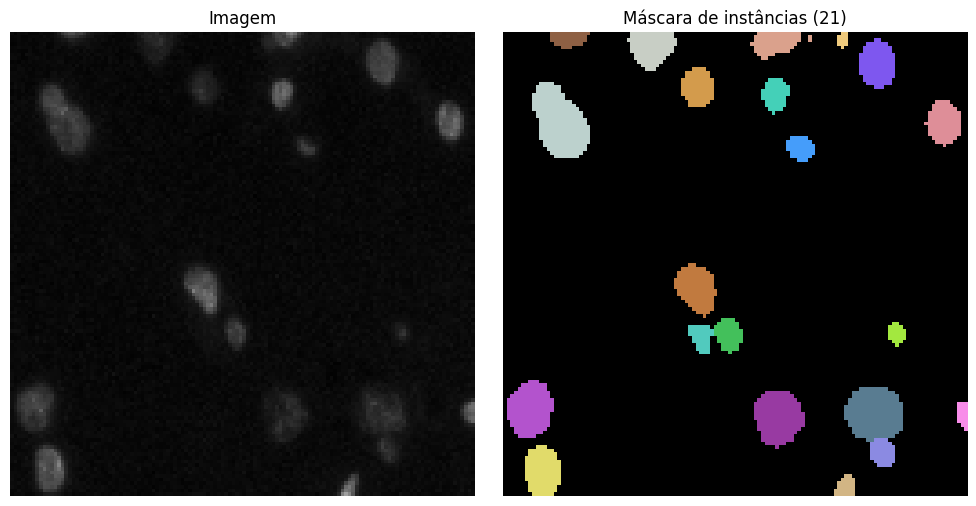

In [22]:
ID = '7bdb668e6127b7eafc837a883f0648002bd063c736f55a4f673e787250a3fb04'
IMAGE_PATH = f'data/stage1_test/{ID}/images/{ID}.png'

img_resized, instance_map = run_inference_on_image(IMAGE_PATH, model, device)
colored_mask, count = colorize_instances(instance_map)

print(f'Número de instâncias detectadas: {count}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_resized)
axes[0].set_title('Imagem')
axes[0].axis('off')

axes[1].imshow(colored_mask)
axes[1].set_title(f'Máscara de instâncias ({count})')
axes[1].axis('off')

plt.tight_layout()
plt.show()